In [55]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

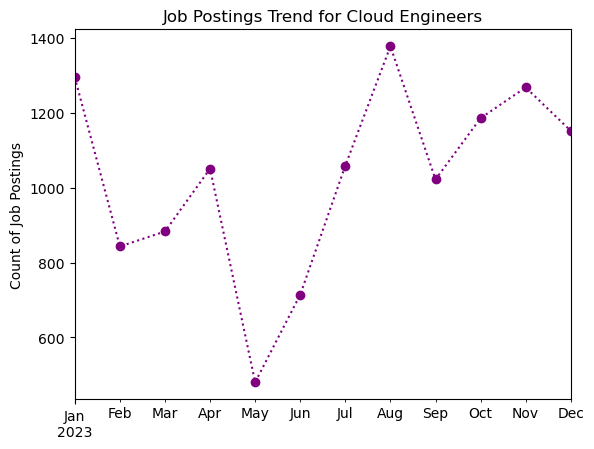

In [104]:
df_ce = df[df['job_title_short'] == 'Cloud Engineer'].copy()

df_ce['Month'] = df_ce['job_posted_date'].dt.to_period('M')
df_ce = df_ce.value_counts('Month').reset_index()
df_ce.sort_values(by='Month', inplace=True)

ax = df_ce.plot(
    kind='line',
    x='Month',
    y='count',
    linestyle= ':',
    color='purple',
    marker='o'
)

ax.set_title('Job Postings Trend for Cloud Engineers')
ax.legend().set_visible(False)
ax.set_ylabel('Count of Job Postings')
ax.set_xlabel('')
plt.show()



